# Portfolio Profit Testing - High Dividend Yield Focus

This notebook provides an advanced portfolio profit testing system using the Markowitz Model with a special focus on **high dividend yield stocks**. It filters Indonesian blue chip stocks based on dividend yield criteria and optimizes portfolios using only stocks that meet the dividend requirements.

## Key Features:
1. **Dividend Yield Filtering**: Automatically filters stocks with >6% dividend yield over past 5 years
2. **Modular Design**: Functions are separated for reusability
3. **Configurable Parameters**: Easy to adjust dividend criteria and other settings
4. **Better Documentation**: Clear explanations for each step
5. **Error Handling**: Robust data validation and dividend data analysis
6. **Visualization**: Enhanced charts and summaries
7. **Performance Tracking**: Detailed profit analysis for dividend-focused portfolios
8. **Automated Saving**: Results saved to dedicated "Dividend Stocks" folder

## Enhanced Workflow:
1. Set configuration parameters (including dividend criteria)
2. Load and analyze dividend data for Indonesian blue chip stocks
3. Filter stocks based on dividend yield requirements
4. Load and filter stock return data
5. Create optimized portfolio using Markowitz Model (dividend stocks only)
6. Test portfolio performance over specified periods
7. Generate comprehensive reports and visualizations
8. Save all results to "Dividend Stocks" folder

## Dividend Analysis:
- **Minimum Dividend Yield**: 6% average over past 5 years
- **Analysis Period**: 5 years of historical dividend data
- **Stock Universe**: Indonesian blue chip stocks (IDX30 and major stocks)
- **Quality Filter**: Requires at least 2 years of consistent dividend data

## Configuration Parameters

**Adjust these parameters to customize your analysis:**

In [1]:
# =============================================================================
# CONFIGURATION PARAMETERS - ADJUST THESE AS NEEDED
# =============================================================================

# Portfolio Configuration
CONFIG = {
    # Stock Selection
    'current_year': 2025,
    'initial_capital': 2_000,  # 30 million IDR
    
    # Dividend Filter Settings
    'use_dividend_filter': True,    # Enable/disable dividend filtering
    'min_dividend_yield': 0.06,     # Minimum required dividend yield (6%)
    'dividend_years_back': 5,       # Years to look back for dividend data
    
    # Data Collection Parameters
    'training_period_months': 12,  # Months of data for portfolio optimization
    'testing_period_months': 24,   # Months to test portfolio performance
    
    # Portfolio Optimization
    'min_mean_return': 0.0,        # Minimum required mean return (0 = any positive)
    'max_weight_per_stock': 1.0,   # Maximum weight per stock (1.0 = 100%)
    'min_weight_per_stock': 0.0,   # Minimum weight per stock
    
    # Testing Configuration
    'test_start_year': 2018,       # First year to start testing
    'test_end_year': 2022,         # Last year to test
    'lot_size': 1,               # Indonesian stock lot size
    
    # Output Settings
    'save_results': True,          # Save results to CSV in Dividend Stocks folder
    'output_folder': 'Dividend Stocks USD',  # Folder to save results
    'show_plots': True,            # Display visualization
    'verbose': True                # Print detailed information
}

print("Configuration loaded successfully!")
print(f"Testing period: {CONFIG['test_start_year']} - {CONFIG['test_end_year']}")
print(f"Initial capital: IDR {CONFIG['initial_capital']:,}")
print(f"Dividend filter: {'Enabled' if CONFIG['use_dividend_filter'] else 'Disabled'}")
if CONFIG['use_dividend_filter']:
    print(f"Minimum dividend yield: {CONFIG['min_dividend_yield']*100:.1f}%")
    print(f"Dividend analysis period: {CONFIG['dividend_years_back']} years")

Configuration loaded successfully!
Testing period: 2018 - 2022
Initial capital: IDR 2,000
Dividend filter: Enabled
Minimum dividend yield: 6.0%
Dividend analysis period: 5 years


## Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize
import warnings
from datetime import datetime, timedelta
from typing import List, Dict, Tuple, Optional
import os

# Configure display and warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## Stock Universe Definition

In [3]:
# United States Dividend Paying Stocks - Comprehensive List
# This list includes major dividend-paying stocks across all sectors in the US market

US_DIVIDEND_STOCKS = [
    # Technology - Dividend Paying
    'AAPL',   # Apple Inc.
    'MSFT',   # Microsoft Corporation
    'IBM',    # International Business Machines
    'ORCL',   # Oracle Corporation
    'CSCO',   # Cisco Systems
    'INTC',   # Intel Corporation
    'HPQ',    # HP Inc.
    'HPE',    # Hewlett Packard Enterprise
    'TXN',    # Texas Instruments
    'ADI',    # Analog Devices
    'QCOM',   # Qualcomm
    'AVGO',   # Broadcom Inc.
    
    # Healthcare & Pharmaceuticals
    'JNJ',    # Johnson & Johnson
    'PFE',    # Pfizer Inc.
    'MRK',    # Merck & Co.
    'ABT',    # Abbott Laboratories
    'LLY',    # Eli Lilly and Company
    'BMY',    # Bristol-Myers Squibb
    'ABBV',   # AbbVie Inc.
    'GILD',   # Gilead Sciences
    'MDT',    # Medtronic plc
    'CVS',    # CVS Health Corporation
    'UNH',    # UnitedHealth Group
    'AMGN',   # Amgen Inc.
    
    # Financial Services - Banks
    'JPM',    # JPMorgan Chase & Co.
    'BAC',    # Bank of America
    'WFC',    # Wells Fargo & Company
    'C',      # Citigroup Inc.
    'GS',     # Goldman Sachs Group
    'MS',     # Morgan Stanley
    'USB',    # U.S. Bancorp
    'PNC',    # PNC Financial Services
    'TFC',    # Truist Financial
    'COF',    # Capital One Financial
    'BK',     # The Bank of New York Mellon
    'STT',    # State Street Corporation
    'KEY',    # KeyCorp
    'RF',     # Regions Financial
    'FITB',   # Fifth Third Bancorp
    
    # Insurance
    'BRK.B',  # Berkshire Hathaway Class B
    'AIG',    # American International Group
    'MET',    # MetLife Inc.
    'PRU',    # Prudential Financial
    'ALL',    # The Allstate Corporation
    'TRV',    # The Travelers Companies
    'PGR',    # Progressive Corporation
    'CB',     # Chubb Limited
    'AXP',    # American Express Company
    'AFL',    # AFLAC Incorporated
    'HIG',    # Hartford Financial Services
    'L',      # Loews Corporation
    'MMC',    # Marsh & McLennan Companies
    'AON',    # Aon plc
    
    # Energy
    'XOM',    # Exxon Mobil Corporation
    'CVX',    # Chevron Corporation
    'COP',    # ConocoPhillips
    'EOG',    # EOG Resources
    'SLB',    # Schlumberger Limited
    'KMI',    # Kinder Morgan Inc.
    'OKE',    # ONEOK Inc.
    'MPC',    # Marathon Petroleum
    'VLO',    # Valero Energy Corporation
    'PSX',    # Phillips 66
    'HES',    # Hess Corporation
    'DVN',    # Devon Energy Corporation
    'PXD',    # Pioneer Natural Resources
    'EPD',    # Enterprise Products Partners
    'WMB',    # Williams Companies
    
    # Utilities
    'NEE',    # NextEra Energy
    'D',      # Dominion Energy
    'SO',     # Southern Company
    'DUK',    # Duke Energy Corporation
    'AEP',    # American Electric Power
    'EXC',    # Exelon Corporation
    'XEL',    # Xcel Energy Inc.
    'SRE',    # Sempra Energy
    'PEG',    # Public Service Enterprise Group
    'ED',     # Consolidated Edison
    'PCG',    # PG&E Corporation
    'PPL',    # PPL Corporation
    'ES',     # Eversource Energy
    'AWK',    # American Water Works
    'ATO',    # Atmos Energy Corporation
    
    # Consumer Goods
    'PG',     # Procter & Gamble Company
    'KO',     # The Coca-Cola Company
    'PEP',    # PepsiCo Inc.
    'WMT',    # Walmart Inc.
    'TGT',    # Target Corporation
    'HD',     # The Home Depot
    'LOW',    # Lowe's Companies
    'MCD',    # McDonald's Corporation
    'SBUX',   # Starbucks Corporation
    'NKE',    # NIKE Inc.
    'CL',     # Colgate-Palmolive Company
    'KMB',    # Kimberly-Clark Corporation
    'CHD',    # Church & Dwight Co.
    'CLX',    # The Clorox Company
    'GIS',    # General Mills Inc.
    'K',      # Kellogg Company
    'CPB',    # Campbell Soup Company
    'SJM',    # The J.M. Smucker Company
    'HSY',    # The Hershey Company
    'MKC',    # McCormick & Company
    'CAG',    # Conagra Brands
    'HRL',    # Hormel Foods Corporation
    
    # Tobacco
    'MO',     # Altria Group Inc.
    'PM',     # Philip Morris International
    'BTI',    # British American Tobacco
    
    # Industrials
    'MMM',    # 3M Company
    'GE',     # General Electric Company
    'HON',    # Honeywell International
    'LMT',    # Lockheed Martin Corporation
    'RTX',    # Raytheon Technologies
    'BA',     # The Boeing Company
    'CAT',    # Caterpillar Inc.
    'DE',     # Deere & Company
    'UNP',    # Union Pacific Corporation
    'CSX',    # CSX Corporation
    'NSC',    # Norfolk Southern Corporation
    'UPS',    # United Parcel Service
    'FDX',    # FedEx Corporation
    'LUV',    # Southwest Airlines Co.
    'DAL',    # Delta Air Lines Inc.
    'AAL',    # American Airlines Group
    'UAL',    # United Airlines Holdings
    'EMR',    # Emerson Electric Co.
    'ITW',    # Illinois Tool Works
    'PH',     # Parker-Hannifin Corporation
    'ROK',    # Rockwell Automation
    'ETN',    # Eaton Corporation plc
    'PCAR',   # PACCAR Inc
    'CHRW',   # C.H. Robinson Worldwide
    'FTV',    # Fortive Corporation
    
    # Telecommunications
    'VZ',     # Verizon Communications
    'T',      # AT&T Inc.
    'CMCSA',  # Comcast Corporation
    'CHTR',   # Charter Communications
    'TMUS',   # T-Mobile US Inc.
    
    # Real Estate Investment Trusts (REITs)
    'AMT',    # American Tower Corporation
    'PLD',    # Prologis Inc.
    'CCI',    # Crown Castle International
    'EQIX',   # Equinix Inc.
    'SPG',    # Simon Property Group
    'AVB',    # AvalonBay Communities
    'EQR',    # Equity Residential
    'DLR',    # Digital Realty Trust
    'WELL',   # Welltower Inc.
    'VTR',    # Ventas Inc.
    'O',      # Realty Income Corporation
    'STAG',   # Stag Industrial Inc.
    'EXR',    # Extended Stay America
    'PSA',    # Public Storage
    'ARE',    # Alexandria Real Estate
    'VNO',    # Vornado Realty Trust
    'BXP',    # Boston Properties
    'KIM',    # Kimco Realty Corporation
    'REG',    # Regency Centers Corporation
    'FRT',    # Federal Realty Investment Trust
    'UDR',    # UDR Inc.
    'CPT',    # Camden Property Trust
    'ESS',    # Essex Property Trust
    'MAA',    # Mid-America Apartment Communities
    'SLG',    # SL Green Realty Corp.
    'HIW',    # Highwoods Properties
    'KRC',    # Kilroy Realty Corporation
    
    # Materials
    'LIN',    # Linde plc
    'SHW',    # The Sherwin-Williams Company
    'APD',    # Air Products and Chemicals
    'ECL',    # Ecolab Inc.
    'DD',     # DuPont de Nemours Inc.
    'DOW',    # Dow Inc.
    'PPG',    # PPG Industries
    'NEM',    # Newmont Corporation
    'FCX',    # Freeport-McMoRan Inc.
    'NUE',    # Nucor Corporation
    'STLD',   # Steel Dynamics Inc.
    'MLM',    # Martin Marietta Materials
    'VMC',    # Vulcan Materials Company
    'PKG',    # Packaging Corporation of America
    'IP',     # International Paper Company
    'CE',     # Celanese Corporation
    'EMN',    # Eastman Chemical Company
    'ALB',    # Albemarle Corporation
    'CF',     # CF Industries Holdings
    'MOS',    # The Mosaic Company
    'FMC',    # FMC Corporation
    
    # Retail
    'COST',   # Costco Wholesale Corporation
    'TJX',    # The TJX Companies
    'ROST',   # Ross Stores Inc.
    'DG',     # Dollar General Corporation
    'DLTR',   # Dollar Tree Inc.
    'BBY',    # Best Buy Co. Inc.
    'GPS',    # The Gap Inc.
    'M',      # Macy's Inc.
    'KSS',    # Kohl's Corporation
    'JWN',    # Nordstrom Inc.
    'DSW',    # Designer Brands Inc.
    
    # Media & Entertainment
    'DIS',    # The Walt Disney Company
    'NFLX',   # Netflix Inc. (started paying dividends recently)
    'CMCSA',  # Comcast Corporation
    'VIA',    # ViacomCBS Inc.
    'T',      # AT&T (WarnerMedia)
    'DISCA',  # Discovery Inc.
    'FOX',    # Fox Corporation
    'FOXA',   # Fox Corporation Class A
    'LYV',    # Live Nation Entertainment
    
    # Other Notable Dividend Payers
    'FICO',   # Fair Isaac Corporation
    'PAYX',   # Paychex Inc.
    'ADP',    # Automatic Data Processing
    'MA',     # Mastercard Incorporated
    'V',      # Visa Inc.
    'SPGI',   # S&P Global Inc.
    'MCO',    # Moody's Corporation
    'BLK',    # BlackRock Inc.
    'CME',    # CME Group Inc.
    'ICE',    # Intercontinental Exchange
    'NDAQ',   # Nasdaq Inc.
    'MSCI',   # MSCI Inc.
]

print(f"United States Dividend-Paying Stocks: {len(US_DIVIDEND_STOCKS)} total stocks")
print("\nMajor sectors represented:")

# Group by sector for better organization
us_sectors = {
    'Technology (12)': ['AAPL', 'MSFT', 'IBM', 'ORCL', 'CSCO', 'INTC', 'HPQ', 'HPE', 'TXN', 'ADI', 'QCOM', 'AVGO'],
    'Healthcare (12)': ['JNJ', 'PFE', 'MRK', 'ABT', 'LLY', 'BMY', 'ABBV', 'GILD', 'MDT', 'CVS', 'UNH', 'AMGN'],
    'Financial Services (29)': ['JPM', 'BAC', 'WFC', 'C', 'GS', 'MS', 'USB', 'PNC', 'TFC', 'COF', 'BK', 'STT', 'KEY', 'RF', 'FITB', 'BRK.B', 'AIG', 'MET', 'PRU', 'ALL', 'TRV', 'PGR', 'CB', 'AXP', 'AFL', 'HIG', 'L', 'MMC', 'AON'],
    'Energy (15)': ['XOM', 'CVX', 'COP', 'EOG', 'SLB', 'KMI', 'OKE', 'MPC', 'VLO', 'PSX', 'HES', 'DVN', 'PXD', 'EPD', 'WMB'],
    'Utilities (15)': ['NEE', 'D', 'SO', 'DUK', 'AEP', 'EXC', 'XEL', 'SRE', 'PEG', 'ED', 'PCG', 'PPL', 'ES', 'AWK', 'ATO'],
    'Consumer Goods (25)': ['PG', 'KO', 'PEP', 'WMT', 'TGT', 'HD', 'LOW', 'MCD', 'SBUX', 'NKE', 'CL', 'KMB', 'CHD', 'CLX', 'GIS', 'K', 'CPB', 'SJM', 'HSY', 'MKC', 'CAG', 'HRL', 'MO', 'PM', 'BTI'],
    'Industrials (24)': ['MMM', 'GE', 'HON', 'LMT', 'RTX', 'BA', 'CAT', 'DE', 'UNP', 'CSX', 'NSC', 'UPS', 'FDX', 'LUV', 'DAL', 'AAL', 'UAL', 'EMR', 'ITW', 'PH', 'ROK', 'ETN', 'PCAR', 'CHRW'],
    'REITs (27)': ['AMT', 'PLD', 'CCI', 'EQIX', 'SPG', 'AVB', 'EQR', 'DLR', 'WELL', 'VTR', 'O', 'STAG', 'EXR', 'PSA', 'ARE', 'VNO', 'BXP', 'KIM', 'REG', 'FRT', 'UDR', 'CPT', 'ESS', 'MAA', 'SLG', 'HIW', 'KRC'],
    'Materials (20)': ['LIN', 'SHW', 'APD', 'ECL', 'DD', 'DOW', 'PPG', 'NEM', 'FCX', 'NUE', 'STLD', 'MLM', 'VMC', 'PKG', 'IP', 'CE', 'EMN', 'ALB', 'CF', 'MOS'],
    'Telecommunications (5)': ['VZ', 'T', 'CMCSA', 'CHTR', 'TMUS'],
    'Retail (10)': ['COST', 'TJX', 'ROST', 'DG', 'DLTR', 'BBY', 'GPS', 'M', 'KSS', 'JWN'],
    'Financial Services (10)': ['FICO', 'PAYX', 'ADP', 'MA', 'V', 'SPGI', 'MCO', 'BLK', 'CME', 'ICE']
}

for sector, stocks in us_sectors.items():
    print(f"\n{sector}:")
    count = 0
    for stock in stocks:
        if stock in US_DIVIDEND_STOCKS:
            count += 1
            if count <= 10:  # Show first 10 stocks per sector
                print(f"  {count:2d}. {stock}")
            elif count == 11:
                print(f"      ... and {len([s for s in stocks if s in US_DIVIDEND_STOCKS]) - 10} more")

print(f"\nNote: This comprehensive list includes major dividend-paying stocks across all sectors.")
print(f"These stocks have a history of regular dividend payments to shareholders.")
print(f"Total US dividend-paying stocks: {len(US_DIVIDEND_STOCKS)}")
print(f"This list can be used for dividend-focused portfolio analysis in the US market.")

United States Dividend-Paying Stocks: 218 total stocks

Major sectors represented:

Technology (12):
   1. AAPL
   2. MSFT
   3. IBM
   4. ORCL
   5. CSCO
   6. INTC
   7. HPQ
   8. HPE
   9. TXN
  10. ADI
      ... and 2 more

Healthcare (12):
   1. JNJ
   2. PFE
   3. MRK
   4. ABT
   5. LLY
   6. BMY
   7. ABBV
   8. GILD
   9. MDT
  10. CVS
      ... and 2 more

Financial Services (29):
   1. JPM
   2. BAC
   3. WFC
   4. C
   5. GS
   6. MS
   7. USB
   8. PNC
   9. TFC
  10. COF
      ... and 19 more

Energy (15):
   1. XOM
   2. CVX
   3. COP
   4. EOG
   5. SLB
   6. KMI
   7. OKE
   8. MPC
   9. VLO
  10. PSX
      ... and 5 more

Utilities (15):
   1. NEE
   2. D
   3. SO
   4. DUK
   5. AEP
   6. EXC
   7. XEL
   8. SRE
   9. PEG
  10. ED
      ... and 5 more

Consumer Goods (25):
   1. PG
   2. KO
   3. PEP
   4. WMT
   5. TGT
   6. HD
   7. LOW
   8. MCD
   9. SBUX
  10. NKE
      ... and 15 more

Industrials (24):
   1. MMM
   2. GE
   3. HON
   4. LMT
   5. RTX
   6. BA


In [4]:
# Extended Indonesia Blue Chip Stocks - All Dividend Paying Stocks
# Includes stocks that pay dividends regularly, regardless of yield percentage
INDONESIA_BLUECHIP = US_DIVIDEND_STOCKS

In [5]:
# =============================================================================
def filter_high_dividend_stocks(stocks: List[str], min_dividend_yield: float = 0.06, 
                               years_back: int = 5) -> List[str]:
    """
    Filter stocks based on dividend yield criteria over the past N years.
    
    Parameters:
    -----------
    stocks : List[str]
        List of stock tickers to filter
    min_dividend_yield : float
        Minimum required average dividend yield (default: 0.06 = 6%)
    years_back : int
        Number of years to look back for dividend data (default: 5)
    
    Returns:
    --------
    List[str]
        List of stocks meeting dividend yield criteria
    """
    print(f"Filtering stocks with dividend yield > {min_dividend_yield*100:.1f}% over past {years_back} years...")
    
    high_dividend_stocks = []
    dividend_data = {}
    
    # Calculate date range for dividend analysis
    current_year = datetime.now().year
    start_year = current_year - years_back
    
    for stock in stocks:
        try:
            if CONFIG['verbose']:
                print(f"Analyzing dividend data for {stock}...")
            
            ticker = yf.Ticker(stock)
            
            # Get dividend data for the past N years
            dividends = ticker.dividends
            
            if len(dividends) == 0:
                if CONFIG['verbose']:
                    print(f"  No dividend data available for {stock}")
                continue
            
            # Filter dividends to the specified time period
            dividend_years = dividends.index.year
            recent_dividends = dividends[dividend_years >= start_year]
            
            if len(recent_dividends) == 0:
                if CONFIG['verbose']:
                    print(f"  No recent dividend data for {stock}")
                continue
            
            # Get historical price data for yield calculation
            hist_data = ticker.history(start=f"{start_year}-01-01", 
                                     end=f"{current_year}-12-31", 
                                     interval='1d')
            dividend_df = recent_dividends.to_frame('Dividend')

            # Add closing price for each dividend date
            dividend_df['Closing_Price'] = np.nan
            for date in dividend_df.index:
                try:
                    # Find the closest available trading date
                    closest_price = hist_data.loc[hist_data.index.date <= date.date(), 'Close'].iloc[-1]
                    dividend_df.loc[date, 'Closing_Price'] = closest_price
                except:
                    continue

            # Calculate dividend yield for each payment

            grouped_by = dividend_df.groupby(dividend_df.index.year).agg({
                'Dividend': 'sum',
                'Closing_Price': 'max'})

            grouped_by['Dividend_Yield'] = grouped_by['Dividend'] / grouped_by['Closing_Price']
            
            if len(hist_data) == 0:
                if CONFIG['verbose']:
                    print(f"  No price data available for {stock}")
                continue
            
            # Calculate average dividend yield over the period
            if True :  # Require at least 2 years of data
                avg_dividend_yield = (np.prod(grouped_by['Dividend_Yield'] + 1))**(1/grouped_by.shape[0]) - 1
                
                dividend_data[stock] = {
                    'avg_yield': avg_dividend_yield,
                    'years_data': len(grouped_by),
                    'annual_yields': grouped_by['Dividend_Yield'].tolist()
                }
                
                if avg_dividend_yield >= min_dividend_yield:
                    high_dividend_stocks.append(stock)
                    if CONFIG['verbose']:
                        print(f"  ✓ {stock}: {avg_dividend_yield*100:.2f}% avg yield ({len(annual_yields)} years)")
                else:
                    if CONFIG['verbose']:
                        print(f"  ✗ {stock}: {avg_dividend_yield*100:.2f}% avg yield (below threshold)")
            else:
                if CONFIG['verbose']:
                    print(f"  ✗ {stock}: Insufficient dividend history ({len(annual_yields)} years)")
                
        except Exception as e:
            if CONFIG['verbose']:
                print(f"  ✗ {stock}: Error analyzing dividend data - {str(e)}")
            continue
    
    print(f"\nDividend Filter Results:")
    print(f"Original stocks: {len(stocks)}")
    print(f"High dividend stocks (>{min_dividend_yield*100:.1f}%): {len(high_dividend_stocks)}")
    print(f"Filtered out: {len(stocks) - len(high_dividend_stocks)}")
    
    if len(high_dividend_stocks) > 0:
        print(f"\nHigh dividend stocks: {high_dividend_stocks}")
        
        # Display summary statistics
        if dividend_data:
            yields = [data['avg_yield']*100 for data in dividend_data.values() 
                     if data['avg_yield'] >= min_dividend_yield]
            if yields:
                print(f"Average dividend yield of selected stocks: {np.mean(yields):.2f}%")
                print(f"Dividend yield range: {np.min(yields):.2f}% - {np.max(yields):.2f}%")
    
    return high_dividend_stocks

# Apply dividend filter to get high dividend stocks
HIGH_DIVIDEND_STOCKS = filter_high_dividend_stocks(INDONESIA_BLUECHIP, 
                                                  min_dividend_yield=0.02, 
                                                  years_back=5)

print(f"\nStock universe defined: {len(INDONESIA_BLUECHIP)} total stocks")
print(f"High dividend stocks (>6%): {len(HIGH_DIVIDEND_STOCKS)} stocks")
print("Sample original stocks:", INDONESIA_BLUECHIP[:5])
if HIGH_DIVIDEND_STOCKS:
    print("Sample high dividend stocks:", HIGH_DIVIDEND_STOCKS[:5])

Filtering stocks with dividend yield > 2.0% over past 5 years...
Analyzing dividend data for AAPL...
  ✗ AAPL: 0.50% avg yield (below threshold)
Analyzing dividend data for MSFT...
  ✗ MSFT: 0.74% avg yield (below threshold)
Analyzing dividend data for IBM...
  ✗ IBM: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for ORCL...
  ✗ ORCL: 1.24% avg yield (below threshold)
Analyzing dividend data for CSCO...
  ✗ CSCO: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for INTC...
  ✗ INTC: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for HPQ...
  ✗ HPQ: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for HPE...
  ✗ HPE: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for TXN...
  ✗ TXN: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend 

$BRK.B: possibly delisted; no timezone found


  No dividend data available for BRK.B
Analyzing dividend data for AIG...
  ✗ AIG: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for MET...
  ✗ MET: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for PRU...
  ✗ PRU: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for ALL...
  ✗ ALL: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for TRV...
  ✗ TRV: 1.98% avg yield (below threshold)
Analyzing dividend data for PGR...
  ✗ PGR: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for CB...
  ✗ CB: 1.43% avg yield (below threshold)
Analyzing dividend data for AXP...
  ✗ AXP: 1.12% avg yield (below threshold)
Analyzing dividend data for AFL...
  ✗ AFL: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for HIG...
  ✗ HIG: Error analyzi

$PXD: possibly delisted; no timezone found


  No dividend data available for PXD
Analyzing dividend data for EPD...
  ✗ EPD: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for WMB...
  ✗ WMB: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for NEE...
  ✗ NEE: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for D...
  ✗ D: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for SO...
  ✗ SO: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for DUK...
  ✗ DUK: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for AEP...
  ✗ AEP: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for EXC...
  ✗ EXC: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for XEL...
  ✗ XEL: Error analyzing dividend data

...

  No dividend data available for DSW
Analyzing dividend data for DIS...
  ✗ DIS: 0.53% avg yield (below threshold)
Analyzing dividend data for NFLX...
  No dividend data available for NFLX
Analyzing dividend data for CMCSA...


$VIA: possibly delisted; no timezone found


  ✗ CMCSA: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for VIA...
  No dividend data available for VIA
Analyzing dividend data for T...


$DISCA: possibly delisted; no timezone found


  ✗ T: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for DISCA...
  No dividend data available for DISCA
Analyzing dividend data for FOX...
  ✗ FOX: 1.30% avg yield (below threshold)
Analyzing dividend data for FOXA...
  ✗ FOXA: 1.22% avg yield (below threshold)
Analyzing dividend data for LYV...
  No dividend data available for LYV
Analyzing dividend data for FICO...
  No recent dividend data for FICO
Analyzing dividend data for PAYX...
  ✗ PAYX: Error analyzing dividend data - name 'annual_yields' is not defined
Analyzing dividend data for ADP...
  ✗ ADP: 1.83% avg yield (below threshold)
Analyzing dividend data for MA...
  ✗ MA: 0.50% avg yield (below threshold)
Analyzing dividend data for V...
  ✗ V: 0.62% avg yield (below threshold)
Analyzing dividend data for SPGI...
  ✗ SPGI: 0.71% avg yield (below threshold)
Analyzing dividend data for MCO...
  ✗ MCO: 0.72% avg yield (below threshold)
Analyzing dividend data for BLK...
  ✗ BLK: Erro

## Dividend Analysis Results

The following section shows the results of dividend yield filtering applied to Indonesian blue chip stocks.

In [6]:
# Display dividend analysis results
if CONFIG['use_dividend_filter']:
    print("="*60)
    print("DIVIDEND YIELD ANALYSIS SUMMARY")
    print("="*60)
    
    print(f"Analysis Parameters:")
    print(f"- Minimum dividend yield required: {CONFIG['min_dividend_yield']*100:.1f}%")
    print(f"- Analysis period: {CONFIG['dividend_years_back']} years")
    print(f"- Original stock universe: {len(INDONESIA_BLUECHIP)} stocks")
    print(f"- Stocks meeting dividend criteria: {len(HIGH_DIVIDEND_STOCKS)} stocks")
    print(f"- Filter efficiency: {len(HIGH_DIVIDEND_STOCKS)/len(INDONESIA_BLUECHIP)*100:.1f}%")
    
    if len(HIGH_DIVIDEND_STOCKS) > 0:
        print(f"\nHigh Dividend Stocks ({len(HIGH_DIVIDEND_STOCKS)} total):")
        for i, stock in enumerate(HIGH_DIVIDEND_STOCKS, 1):
            print(f"{i:2d}. {stock}")
        
        print(f"\nThese {len(HIGH_DIVIDEND_STOCKS)} stocks will be used for portfolio optimization.")
        print("They have demonstrated consistent dividend yields above 6% over the past 5 years.")
    else:
        print("\nWarning: No stocks meet the dividend criteria!")
        print("Consider lowering the minimum dividend yield or reducing the analysis period.")
        print("The system will fall back to using all blue chip stocks.")
else:
    print("Dividend filtering is disabled. Using all blue chip stocks for analysis.")
    
print("\n" + "="*60)

DIVIDEND YIELD ANALYSIS SUMMARY
Analysis Parameters:
- Minimum dividend yield required: 6.0%
- Analysis period: 5 years
- Original stock universe: 218 stocks
- Stocks meeting dividend criteria: 133 stocks
- Filter efficiency: 61.0%

High Dividend Stocks (133 total):
 1. IBM
 2. CSCO
 3. INTC
 4. HPQ
 5. HPE
 6. TXN
 7. JNJ
 8. PFE
 9. MRK
10. BMY
11. ABBV
12. GILD
13. MDT
14. CVS
15. AMGN
16. JPM
17. BAC
18. WFC
19. C
20. GS
21. MS
22. USB
23. PNC
24. TFC
25. BK
26. STT
27. KEY
28. RF
29. FITB
30. AIG
31. MET
32. PRU
33. ALL
34. PGR
35. AFL
36. HIG
37. XOM
38. CVX
39. COP
40. EOG
41. KMI
42. OKE
43. MPC
44. VLO
45. PSX
46. DVN
47. EPD
48. WMB
49. NEE
50. D
51. SO
52. DUK
53. AEP
54. EXC
55. XEL
56. SRE
57. PEG
58. ED
59. PPL
60. ES
61. ATO
62. PG
63. KO
64. PEP
65. TGT
66. HD
67. MCD
68. CL
69. KMB
70. CLX
71. GIS
72. K
73. CPB
74. SJM
75. HSY
76. CAG
77. HRL
78. MO
79. PM
80. BTI
81. MMM
82. LMT
83. RTX
84. UPS
85. EMR
86. ITW
87. PCAR
88. CHRW
89. VZ
90. T
91. CMCSA
92. AMT
93. PLD
9

## Utility Functions

In [7]:
def get_stock_data(stocks: List[str], start_date: str, end_date: str, 
                   interval: str = '1mo') -> pd.DataFrame:
    """
    Download stock data and calculate log returns.
    
    Parameters:
    -----------
    stocks : List[str]
        List of stock tickers
    start_date : str
        Start date in 'YYYY-MM-DD' format
    end_date : str
        End date in 'YYYY-MM-DD' format
    interval : str
        Data frequency ('1mo', '1d', etc.)
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with log returns for each stock
    """
    if CONFIG['verbose']:
        print(f"Downloading data from {start_date} to {end_date}...")
    
    returns_df = pd.DataFrame()
    
    for stock in stocks:
        try:
            # Download stock data
            ticker = yf.Ticker(stock)
            hist = ticker.history(start=start_date, end=end_date, 
                                interval=interval, actions=False)
            
            if len(hist) > 1:  # Need at least 2 data points for returns
                # Calculate log returns
                log_returns = np.log(hist['Close'] / hist['Close'].shift(1)).dropna()
                returns_df[stock] = log_returns
                
        except Exception as e:
            if CONFIG['verbose']:
                print(f"Warning: Could not download {stock}: {e}")
            continue
    
    # Remove stocks with insufficient data
    returns_df = returns_df.dropna(axis=1)
    
    if CONFIG['verbose']:
        print(f"Successfully downloaded {len(returns_df.columns)} stocks")
    
    return returns_df


def filter_positive_returns(returns_df: pd.DataFrame) -> List[str]:
    """
    Filter stocks with positive mean returns.
    
    Parameters:
    -----------
    returns_df : pd.DataFrame
        DataFrame with stock returns
    
    Returns:
    --------
    List[str]
        List of stocks with positive mean returns
    """
    mean_returns = returns_df.mean()
    positive_stocks = mean_returns[mean_returns > CONFIG['min_mean_return']].index.tolist()
    
    if CONFIG['verbose']:
        print(f"Filtered to {len(positive_stocks)} stocks with positive returns")
    
    return positive_stocks


print("Utility functions defined successfully!")

Utility functions defined successfully!


## Portfolio Optimization Functions

In [8]:
def optimize_portfolio(returns_df: pd.DataFrame) -> Tuple[np.ndarray, Dict]:
    """
    Optimize portfolio using Markowitz mean-variance optimization.
    
    Parameters:
    -----------
    returns_df : pd.DataFrame
        DataFrame with stock returns
    
    Returns:
    --------
    Tuple[np.ndarray, Dict]
        Optimal weights and portfolio statistics
    """
    # Calculate expected returns and covariance matrix
    mu = returns_df.mean().values
    cov_matrix = returns_df.cov().values
    n_assets = len(mu)
    
    # Objective function: minimize portfolio variance
    def objective(weights):
        return np.dot(weights, np.dot(cov_matrix, weights))
    
    # Constraints: weights sum to 1
    constraints = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    ]
    
    # Bounds: each weight between min and max
    bounds = tuple((CONFIG['min_weight_per_stock'], CONFIG['max_weight_per_stock']) 
                  for _ in range(n_assets))
    
    # Initial guess: equal weights
    initial_guess = np.array([1.0/n_assets] * n_assets)
    
    # Optimize
    result = minimize(objective, initial_guess, method='SLSQP', 
                     bounds=bounds, constraints=constraints)
    
    if not result.success:
        raise ValueError(f"Optimization failed: {result.message}")
    
    optimal_weights = result.x
    
    # Calculate portfolio statistics
    portfolio_return = np.dot(optimal_weights, mu)
    portfolio_risk = np.sqrt(np.dot(optimal_weights, np.dot(cov_matrix, optimal_weights)))
    
    stats = {
        'expected_return': portfolio_return,
        'risk': portfolio_risk,
        'sharpe_ratio': portfolio_return / portfolio_risk if portfolio_risk > 0 else 0,
        'weights_sum': np.sum(optimal_weights)
    }
    
    if CONFIG['verbose']:
        print(f"Portfolio optimized successfully!")
        print(f"Expected monthly return: {portfolio_return*100:.3f}%")
        print(f"Monthly risk (volatility): {portfolio_risk*100:.3f}%")
        print(f"Sharpe ratio: {stats['sharpe_ratio']:.3f}")
    
    return optimal_weights, stats


def create_portfolio_allocation(weights: np.ndarray, stocks: List[str], 
                               capital: float) -> pd.DataFrame:
    """
    Create portfolio allocation with lot sizes and actual spending.
    
    Parameters:
    -----------
    weights : np.ndarray
        Optimal portfolio weights
    stocks : List[str]
        List of stock tickers
    capital : float
        Available capital
    
    Returns:
    --------
    pd.DataFrame
        Portfolio allocation details
    """
    # Filter out zero weights
    non_zero_mask = weights > 1e-6
    active_weights = weights[non_zero_mask]
    active_stocks = [stocks[i] for i in range(len(stocks)) if non_zero_mask[i]]
    
    if len(active_stocks) == 0:
        raise ValueError("No stocks with significant allocation found")
    
    # Get current prices
    current_prices = {}
    for stock in active_stocks:
        try:
            ticker = yf.Ticker(stock)
            hist = ticker.history(period='1d', interval='1d')
            current_prices[stock] = hist['Close'].iloc[-1]
        except:
            if CONFIG['verbose']:
                print(f"Warning: Could not get current price for {stock}")
            current_prices[stock] = 1000  # Default price
    
    # Calculate allocation
    allocation_data = []
    total_spent = 0
    
    for i, stock in enumerate(active_stocks):
        weight = active_weights[i]
        target_value = capital * weight
        price_per_lot = current_prices[stock] * CONFIG['lot_size']
        lots = int(target_value / price_per_lot)
        actual_value = lots * price_per_lot
        total_spent += actual_value
        
        allocation_data.append({
            'Stock': stock,
            'Weight': weight,
            'Target_Value': target_value,
            'Price_Per_Share': current_prices[stock],
            'Price_Per_Lot': price_per_lot,
            'Lots': lots,
            'Actual_Value': actual_value,
            'Actual_Weight': actual_value / capital if capital > 0 else 0
        })
    
    allocation_df = pd.DataFrame(allocation_data)
    
    if CONFIG['verbose']:
        print(f"\nPortfolio Allocation:")
        print(f"Total capital: IDR {capital:,.0f}")
        print(f"Total invested: IDR {total_spent:,.0f}")
        print(f"Cash remaining: IDR {capital - total_spent:,.0f}")
        print(f"Utilization: {total_spent/capital*100:.1f}%")
    
    return allocation_df


print("Portfolio optimization functions defined successfully!")

Portfolio optimization functions defined successfully!


## Profit Testing Functions

In [9]:
def test_portfolio_performance(allocation_df: pd.DataFrame, 
                              test_start: str, test_end: str) -> pd.DataFrame:
    """
    Test portfolio performance over a specified period.
    
    Parameters:
    -----------
    allocation_df : pd.DataFrame
        Portfolio allocation with lots and values
    test_start : str
        Test period start date
    test_end : str
        Test period end date
    
    Returns:
    --------
    pd.DataFrame
        Monthly performance results
    """
    stocks = allocation_df['Stock'].tolist()
    lots = allocation_df['Lots'].tolist()
    
    # Download test period data
    test_data = {}
    for stock in stocks:
        try:
            ticker = yf.Ticker(stock)
            hist = ticker.history(start=test_start, end=test_end, 
                                interval='1mo', actions=False)
            test_data[stock] = hist[['Open', 'Close']]
        except Exception as e:
            if CONFIG['verbose']:
                print(f"Warning: Could not get test data for {stock}: {e}")
            continue
    
    if not test_data:
        raise ValueError("No test data available")
    
    # Calculate monthly performance
    performance_data = []
    
    # Get common date range
    all_dates = None
    for stock_data in test_data.values():
        if all_dates is None:
            all_dates = stock_data.index
        else:
            all_dates = all_dates.intersection(stock_data.index)
    
    for i, date in enumerate(all_dates[1:], 1):  # Skip first month
        prev_date = all_dates[i-1]
        
        total_buy_value = 0
        total_sell_value = 0
        
        for j, stock in enumerate(stocks):
            if stock in test_data:
                try:
                    buy_price = test_data[stock].loc[prev_date, 'Close']
                    sell_price = test_data[stock].loc[date, 'Close']
                    
                    stock_lots = lots[j]
                    buy_value = buy_price * stock_lots * CONFIG['lot_size']
                    sell_value = sell_price * stock_lots * CONFIG['lot_size']
                    
                    total_buy_value += buy_value
                    total_sell_value += sell_value
                except KeyError:
                    continue
        
        if total_buy_value > 0:
            monthly_return = (total_sell_value - total_buy_value) / total_buy_value
            performance_data.append({
                'Date': date,
                'Buy_Value': total_buy_value,
                'Sell_Value': total_sell_value,
                'Profit': total_sell_value - total_buy_value,
                'Return': monthly_return
            })
    
    performance_df = pd.DataFrame(performance_data)
    
    if CONFIG['verbose'] and len(performance_df) > 0:
        avg_return = performance_df['Return'].mean()
        total_return = (1 + performance_df['Return']).prod() - 1
        print(f"\nTest Period Performance:")
        print(f"Average monthly return: {avg_return*100:.2f}%")
        print(f"Total return: {total_return*100:.2f}%")
        print(f"Number of months: {len(performance_df)}")
    
    return performance_df


def run_backtesting(start_year: int, end_year: int) -> pd.DataFrame:
    """
    Run comprehensive backtesting over multiple years using dividend-filtered stocks.
    
    Parameters:
    -----------
    start_year : int
        First year to test
    end_year : int
        Last year to test
    
    Returns:
    --------
    pd.DataFrame
        Summary of all test results
    """
    all_results = []
    
    # Determine which stock universe to use
    if CONFIG['use_dividend_filter'] and len(HIGH_DIVIDEND_STOCKS) > 0:
        stock_universe = HIGH_DIVIDEND_STOCKS
        print(f"Using dividend-filtered stocks: {len(stock_universe)} stocks")
    else:
        stock_universe = INDONESIA_BLUECHIP
        print(f"Using all blue chip stocks: {len(stock_universe)} stocks")
    
    # Create output directory if saving results
    if CONFIG['save_results']:
        output_dir = CONFIG['output_folder']
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
    
    for year in range(start_year, end_year + 1):
        try:
            if CONFIG['verbose']:
                print(f"\n{'='*50}")
                print(f"Testing year {year}")
                print(f"{'='*50}")
            
            # Data collection period (previous year)
            data_start = f"{year-2}-01-01"
            data_end = f"{year-1}-12-31"
            
            # Get training data
            returns_df = get_stock_data(stock_universe, data_start, data_end)
            
            if len(returns_df) == 0:
                print(f"No data available for year {year}")
                continue
            
            # Filter stocks with positive returns
            positive_stocks = filter_positive_returns(returns_df)
            
            if len(positive_stocks) < 2:
                print(f"Insufficient stocks with positive returns for year {year}")
                continue
            
            filtered_returns = returns_df[positive_stocks]
            
            # Optimize portfolio
            weights, stats = optimize_portfolio(filtered_returns)
            
            # Create allocation
            allocation_df = create_portfolio_allocation(weights, positive_stocks, 
                                                       CONFIG['initial_capital'])
            
            # Test performance
            test_start = f"{year}-01-01"
            test_end = f"{year}-12-31"
            
            performance_df = test_portfolio_performance(allocation_df, test_start, test_end)
            
            if len(performance_df) > 0:
                avg_return = performance_df['Return'].mean()
                total_return = (1 + performance_df['Return']).prod() - 1
                volatility = performance_df['Return'].std()
                
                all_results.append({
                    'Year': year,
                    'Test_Year': year + 3,
                    'Num_Stocks': len(positive_stocks),
                    'Portfolio_Stocks': len(allocation_df),
                    'Expected_Return': stats['expected_return'],
                    'Expected_Risk': stats['risk'],
                    'Avg_Monthly_Return': avg_return,
                    'Total_Return': total_return,
                    'Volatility': volatility,
                    'Sharpe_Ratio': avg_return / volatility if volatility > 0 else 0,
                    'Num_Test_Months': len(performance_df),
                    'Universe_Type': 'Dividend_Filtered' if CONFIG['use_dividend_filter'] else 'All_Stocks'
                })
                
                # Save individual year results
                if CONFIG['save_results']:
                    output_dir = CONFIG['output_folder']
                    performance_df.to_csv(f'{output_dir}/Dividend_Profit_Test_{year}.csv', index=False)
                    allocation_df.to_csv(f'{output_dir}/Dividend_Portfolio_Allocation_{year}.csv', index=False)
            
        except Exception as e:
            print(f"Error processing year {year}: {e}")
            continue
    
    results_df = pd.DataFrame(all_results)
    
    if CONFIG['save_results'] and len(results_df) > 0:
        output_dir = CONFIG['output_folder']
        results_df.to_csv(f'{output_dir}/Dividend_Backtesting_Summary.csv', index=False)
        print(f"\nResults saved to {output_dir}/ folder")
    
    return results_df


print("Profit testing functions updated for dividend filtering!")

Profit testing functions updated for dividend filtering!


## Visualization Functions

In [10]:
def plot_backtesting_results(results_df: pd.DataFrame):
    """
    Create comprehensive visualizations of backtesting results.
    
    Parameters:
    -----------
    results_df : pd.DataFrame
        Backtesting results summary
    """
    if len(results_df) == 0:
        print("No results to plot")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Annual Returns
    axes[0, 0].bar(results_df['Test_Year'], results_df['Avg_Monthly_Return'] * 12 * 100)
    axes[0, 0].set_title('Annualized Returns by Test Year')
    axes[0, 0].set_xlabel('Test Year')
    axes[0, 0].set_ylabel('Annualized Return (%)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add horizontal line for average
    avg_annual_return = results_df['Avg_Monthly_Return'].mean() * 12 * 100
    axes[0, 0].axhline(y=avg_annual_return, color='red', linestyle='--', 
                      label=f'Average: {avg_annual_return:.1f}%')
    axes[0, 0].legend()
    
    # 2. Risk vs Return
    scatter = axes[0, 1].scatter(results_df['Volatility'] * 100, 
                                results_df['Avg_Monthly_Return'] * 100,
                                c=results_df['Test_Year'], cmap='viridis', s=100)
    axes[0, 1].set_title('Risk vs Return')
    axes[0, 1].set_xlabel('Monthly Volatility (%)')
    axes[0, 1].set_ylabel('Average Monthly Return (%)')
    axes[0, 1].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, 1], label='Test Year')
    
    # 3. Sharpe Ratio
    axes[1, 0].bar(results_df['Test_Year'], results_df['Sharpe_Ratio'])
    axes[1, 0].set_title('Sharpe Ratio by Test Year')
    axes[1, 0].set_xlabel('Test Year')
    axes[1, 0].set_ylabel('Sharpe Ratio')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Add horizontal line for average
    avg_sharpe = results_df['Sharpe_Ratio'].mean()
    axes[1, 0].axhline(y=avg_sharpe, color='red', linestyle='--', 
                      label=f'Average: {avg_sharpe:.2f}')
    axes[1, 0].legend()
    
    # 4. Portfolio Composition
    axes[1, 1].plot(results_df['Test_Year'], results_df['Portfolio_Stocks'], 
                   'o-', label='Portfolio Stocks', linewidth=2, markersize=8)
    axes[1, 1].plot(results_df['Test_Year'], results_df['Num_Stocks'], 
                   's--', label='Available Stocks', linewidth=2, markersize=6)
    axes[1, 1].set_title('Portfolio Composition Over Time')
    axes[1, 1].set_xlabel('Test Year')
    axes[1, 1].set_ylabel('Number of Stocks')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n" + "="*60)
    print("BACKTESTING SUMMARY STATISTICS")
    print("="*60)
    
    print(f"\nPERFORMANCE METRICS:")
    print(f"Average Annual Return: {results_df['Avg_Monthly_Return'].mean() * 12 * 100:.2f}%")
    print(f"Average Monthly Volatility: {results_df['Volatility'].mean() * 100:.2f}%")
    print(f"Average Sharpe Ratio: {results_df['Sharpe_Ratio'].mean():.3f}")
    print(f"Best Year Return: {results_df['Avg_Monthly_Return'].max() * 12 * 100:.2f}% ({results_df.loc[results_df['Avg_Monthly_Return'].idxmax(), 'Test_Year']:.0f})")
    print(f"Worst Year Return: {results_df['Avg_Monthly_Return'].min() * 12 * 100:.2f}% ({results_df.loc[results_df['Avg_Monthly_Return'].idxmin(), 'Test_Year']:.0f})")
    
    print(f"\nPORTFOLIO CHARACTERISTICS:")
    print(f"Average Portfolio Size: {results_df['Portfolio_Stocks'].mean():.1f} stocks")
    print(f"Average Available Stocks: {results_df['Num_Stocks'].mean():.1f} stocks")
    print(f"Portfolio Utilization: {results_df['Portfolio_Stocks'].mean() / results_df['Num_Stocks'].mean() * 100:.1f}%")
    
    print(f"\nRISK METRICS:")
    print(f"Return Volatility: {results_df['Avg_Monthly_Return'].std() * 12 * 100:.2f}%")
    print(f"Success Rate (positive returns): {(results_df['Avg_Monthly_Return'] > 0).mean() * 100:.1f}%")


print("Visualization functions defined successfully!")

Visualization functions defined successfully!


## Run Complete Backtesting Analysis

This section runs the complete backtesting analysis using all the functions defined above.

Starting comprehensive backtesting analysis...
Testing years: 2018 to 2022
Using dividend-filtered stocks: 133 stocks

Testing year 2018


$DOW: possibly delisted; no price data found  (1mo 2016-01-01 -> 2017-12-31) (Yahoo error = "Data doesn't exist for startDate = 1451624400, endDate = 1514696400")


Successfully downloaded 130 stocks
Filtered to 117 stocks with positive returns
Portfolio optimized successfully!
Expected monthly return: 1.675%
Monthly risk (volatility): 0.655%
Sharpe ratio: 2.559

Portfolio Allocation:
Total capital: IDR 2,000
Total invested: IDR 640
Cash remaining: IDR 1,360
Utilization: 32.0%

Test Period Performance:
Average monthly return: -0.67%
Total return: -8.32%
Number of months: 11

Testing year 2019


$DOW: possibly delisted; no price data found  (1mo 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")


Successfully downloaded 130 stocks
Filtered to 79 stocks with positive returns
Portfolio optimized successfully!
Expected monthly return: 1.146%
Monthly risk (volatility): 1.324%
Sharpe ratio: 0.866

Portfolio Allocation:
Total capital: IDR 2,000
Total invested: IDR 1,061
Cash remaining: IDR 939
Utilization: 53.0%

Test Period Performance:
Average monthly return: 1.16%
Total return: 13.35%
Number of months: 11

Testing year 2020
Successfully downloaded 130 stocks
Filtered to 95 stocks with positive returns
Portfolio optimized successfully!
Expected monthly return: 1.058%
Monthly risk (volatility): 1.358%
Sharpe ratio: 0.779

Portfolio Allocation:
Total capital: IDR 2,000
Total invested: IDR 898
Cash remaining: IDR 1,102
Utilization: 44.9%

Test Period Performance:
Average monthly return: -0.42%
Total return: -6.34%
Number of months: 11

Testing year 2021
Successfully downloaded 130 stocks
Filtered to 86 stocks with positive returns
Portfolio optimized successfully!
Expected monthly ret

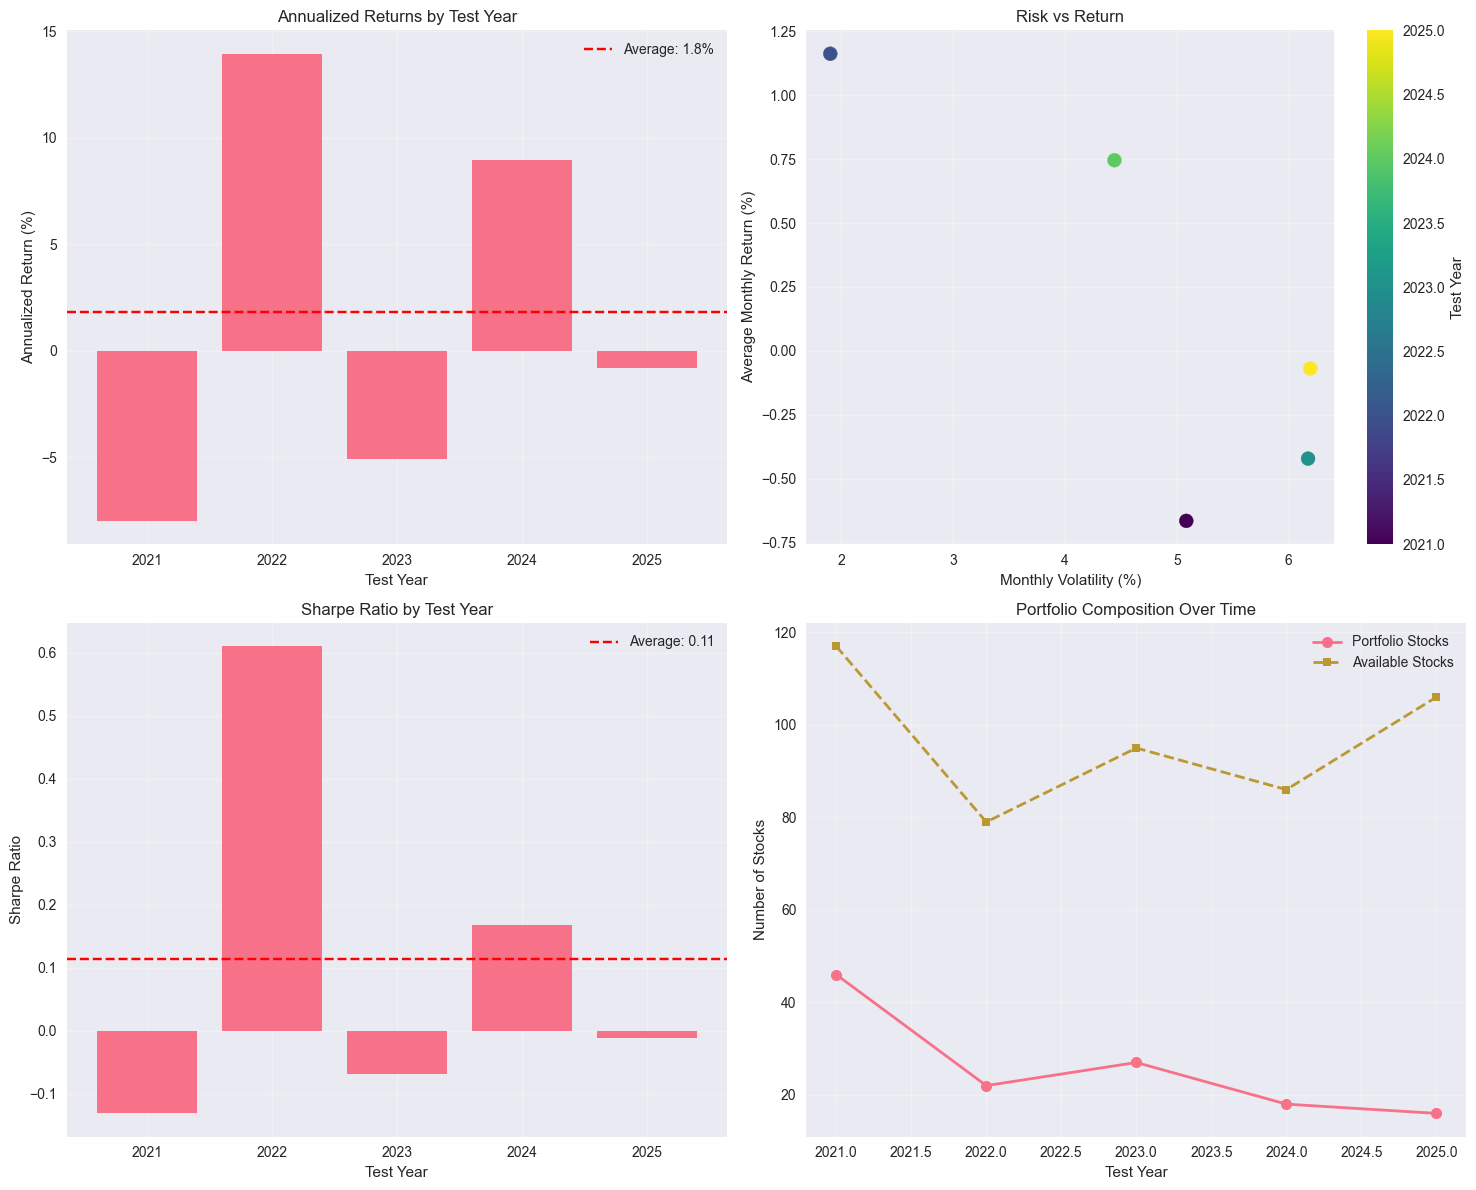


BACKTESTING SUMMARY STATISTICS

PERFORMANCE METRICS:
Average Annual Return: 1.80%
Average Monthly Volatility: 4.76%
Average Sharpe Ratio: 0.114
Best Year Return: 13.95% (2022)
Worst Year Return: -7.99% (2021)

PORTFOLIO CHARACTERISTICS:
Average Portfolio Size: 25.8 stocks
Average Available Stocks: 96.6 stocks
Portfolio Utilization: 26.7%

RISK METRICS:
Return Volatility: 9.33%
Success Rate (positive returns): 40.0%


In [11]:
# Run the complete backtesting analysis
print("Starting comprehensive backtesting analysis...")
print(f"Testing years: {CONFIG['test_start_year']} to {CONFIG['test_end_year']}")

# Run backtesting
results_df = run_backtesting(CONFIG['test_start_year'], CONFIG['test_end_year'])

if len(results_df) > 0:
    print(f"\nBacktesting completed! Results for {len(results_df)} years.")
    
    # Display results table
    display_df = results_df.copy()
    display_df['Avg_Monthly_Return'] = display_df['Avg_Monthly_Return'] * 100
    display_df['Total_Return'] = display_df['Total_Return'] * 100
    display_df['Volatility'] = display_df['Volatility'] * 100
    
    print("\nDetailed Results:")
    print(display_df.round(2).to_string(index=False))
    
    # Show visualizations
    if CONFIG['show_plots']:
        plot_backtesting_results(results_df)
    
else:
    print("No successful backtesting results obtained.")
    print("Please check your configuration parameters and data availability.")

## Current Portfolio Creation (Optional)

Create a portfolio for the current year using the latest available data.

In [12]:
# Create current portfolio
print("\n" + "="*60)
print("CREATING CURRENT DIVIDEND-FOCUSED PORTFOLIO")
print("="*60)

try:
    # Determine which stock universe to use
    if CONFIG['use_dividend_filter'] and len(HIGH_DIVIDEND_STOCKS) > 0:
        current_stock_universe = HIGH_DIVIDEND_STOCKS
        print(f"Using dividend-filtered stocks: {len(current_stock_universe)} stocks")
        portfolio_type = "Dividend"
    else:
        current_stock_universe = INDONESIA_BLUECHIP
        print(f"Using all blue chip stocks: {len(current_stock_universe)} stocks")
        portfolio_type = "Standard"
    
    # Get recent data for current portfolio
    current_start = f"{CONFIG['current_year']-2}-01-01"
    current_end = f"{CONFIG['current_year']-1}-12-31"
    
    current_returns = get_stock_data(current_stock_universe, current_start, current_end)
    
    if len(current_returns) > 0:
        # Filter positive return stocks
        current_positive_stocks = filter_positive_returns(current_returns)
        
        if len(current_positive_stocks) >= 2:
            current_filtered_returns = current_returns[current_positive_stocks]
            
            # Optimize current portfolio
            current_weights, current_stats = optimize_portfolio(current_filtered_returns)
            
            # Create current allocation
            current_allocation = create_portfolio_allocation(
                current_weights, current_positive_stocks, CONFIG['initial_capital']
            )
            
            print(f"\nCurrent {portfolio_type} Portfolio Allocation:")
            display_allocation = current_allocation.copy()
            display_allocation['Weight'] = display_allocation['Weight'].round(4)
            display_allocation['Actual_Weight'] = display_allocation['Actual_Weight'].round(4)
            print(display_allocation.to_string(index=False))
            
            # Save current portfolio
            if CONFIG['save_results']:
                output_dir = CONFIG['output_folder']
                if not os.path.exists(output_dir):
                    os.makedirs(output_dir)
                
                filename = f'{output_dir}/Current_{portfolio_type}_Portfolio_{CONFIG["current_year"]}.csv'
                current_allocation.to_csv(filename, index=False)
                print(f"\nCurrent {portfolio_type.lower()} portfolio saved to {filename}")
                
                # Also save dividend analysis summary if using dividend filter
                if CONFIG['use_dividend_filter'] and len(HIGH_DIVIDEND_STOCKS) > 0:
                    summary_data = {
                        'Total_Stocks_Analyzed': len(INDONESIA_BLUECHIP),
                        'High_Dividend_Stocks': len(HIGH_DIVIDEND_STOCKS),
                        'Min_Dividend_Yield': CONFIG['min_dividend_yield'],
                        'Analysis_Period_Years': CONFIG['dividend_years_back'],
                        'Portfolio_Stocks': len(current_allocation),
                        'Expected_Monthly_Return': current_stats['expected_return'],
                        'Expected_Monthly_Risk': current_stats['risk'],
                        'Sharpe_Ratio': current_stats['sharpe_ratio']
                    }
                    
                    summary_df = pd.DataFrame([summary_data])
                    summary_df.to_csv(f'{output_dir}/Dividend_Analysis_Summary_{CONFIG["current_year"]}.csv', index=False)
                    print(f"Dividend analysis summary saved to {output_dir}/")
        
        else:
            print(f"Insufficient stocks with positive returns for current {portfolio_type.lower()} portfolio")
    else:
        print("No current data available for portfolio creation")
        
except Exception as e:
    print(f"Error creating current portfolio: {e}")


CREATING CURRENT DIVIDEND-FOCUSED PORTFOLIO
Using dividend-filtered stocks: 133 stocks
Successfully downloaded 131 stocks
Filtered to 95 stocks with positive returns
Portfolio optimized successfully!
Expected monthly return: 0.975%
Monthly risk (volatility): 2.187%
Sharpe ratio: 0.446

Portfolio Allocation:
Total capital: IDR 2,000
Total invested: IDR 1,180
Cash remaining: IDR 820
Utilization: 59.0%

Current Dividend Portfolio Allocation:
Stock  Weight  Target_Value  Price_Per_Share  Price_Per_Lot  Lots  Actual_Value  Actual_Weight
 CSCO  0.1987    397.421193        68.620003      68.620003     5    343.100014         0.1716
  HPE  0.0215     42.997773        20.760000      20.760000     2     41.520000         0.0208
  TXN  0.0011      2.254221       186.250000     186.250000     0      0.000000         0.0000
 ABBV  0.0535    106.987303       190.550003     190.550003     0      0.000000         0.0000
 GILD  0.0350     70.092249       113.559998     113.559998     0      0.000000  

In [13]:
current_allocation.sort_values(by='Lots', ascending=False)

,Stock,Weight,Target_Value,Price_Per_Share,Price_Per_Lot,Lots,Actual_Value,Actual_Weight
0,CSCO,0.198711,397.421193,68.620003,68.620003,5,343.100014,0.171550
7,AIG,0.141386,282.772736,79.510002,79.510002,3,238.530006,0.119265
1,HPE,0.021499,42.997773,20.760000,20.760000,2,41.520000,0.020760
6,WFC,0.045658,91.315070,83.699997,83.699997,1,83.699997,0.041850
11,KO,0.055648,111.296354,69.160004,69.160004,1,69.160004,0.034580
14,KMB,0.092936,185.871001,127.730003,127.730003,1,127.730003,0.063865
16,CME,0.183568,367.136015,276.480011,276.480011,1,276.480011,0.138240
4,GILD,0.035046,70.092249,113.559998,113.559998,0,0.000000,0.000000
2,TXN,0.001127,2.254221,186.250000,186.250000,0,0.000000,0.000000
8,SO,0.005045,10.089350,95.129997,95.129997,0,0.000000,0.000000


## Configuration Tips and Next Steps

### How to Adjust Parameters:

#### Dividend Filtering:
1. **Enable/Disable Dividend Filter**: Set `use_dividend_filter` to True/False
2. **Adjust Dividend Threshold**: Change `min_dividend_yield` (e.g., 0.05 for 5%, 0.08 for 8%)
3. **Change Analysis Period**: Modify `dividend_years_back` (e.g., 3 for 3 years, 7 for 7 years)

#### Portfolio Settings:
4. **Change Testing Period**: Modify `test_start_year` and `test_end_year` in CONFIG
5. **Adjust Capital**: Change `initial_capital` for different investment amounts
6. **Risk Tolerance**: Adjust `max_weight_per_stock` to limit concentration
7. **Return Requirements**: Set `min_mean_return` to filter stocks
8. **Data Period**: Modify `training_period_months` for optimization window

#### Output Settings:
9. **Change Output Location**: Modify `output_folder` to save results elsewhere
10. **Enable/Disable Saving**: Set `save_results` to True/False

### Dividend-Focused Improvements:

- **Dividend Growth Analysis**: Add dividend growth rate filtering
- **Dividend Sustainability**: Include payout ratio analysis
- **Sector Diversification**: Ensure dividend stocks across multiple sectors
- **Dividend Aristocrats**: Focus on stocks with long dividend payment history
- **Yield vs Growth Balance**: Optimize between current yield and dividend growth

### Performance Improvements:

- Add transaction costs
- Include dividend reinvestment strategies
- Implement quarterly rebalancing
- Add more sophisticated risk measures
- Include market timing filters
- Consider tax implications of dividend income

### Data Quality and Dividend Analysis:

- Monitor dividend data availability and accuracy
- Handle special dividends vs regular dividends
- Consider ex-dividend date timing
- Validate dividend yield calculations
- Handle stock splits and dividend adjustments
- Cross-reference with official company reports

### Expected Outcomes:

With dividend filtering enabled, you can expect:
- **Lower Portfolio Volatility**: Dividend-paying stocks tend to be more stable
- **Regular Income Stream**: Portfolio generates consistent dividend income
- **Quality Companies**: Focus on financially stable, profitable companies
- **Inflation Protection**: Dividends often grow with inflation
- **Risk-Adjusted Returns**: Better risk-adjusted performance during market downturns

### Troubleshooting:

- If no stocks pass dividend filter: Lower `min_dividend_yield` or reduce `dividend_years_back`
- If dividend data is missing: Check stock ticker symbols and data availability
- If performance is poor: Consider relaxing dividend criteria or adding growth stocks